In [25]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

In [64]:
df = pd.read_csv(
    '../../datasets/roi/regression_roi_dataset.csv'
)

In [57]:
print(df.head())

print(df.shape)

   FeatureType  irradiation  AC_POWER  module_temperature  humidity  \
0  Residential         4.80      2.53               43.85     31.80   
1  Residential         4.60      4.02               37.82     85.52   
2  Residential         5.52      1.62               44.32     37.45   
3  Residential         3.75      5.60               40.73     28.62   
4  Residential         4.62      9.35               41.58     37.03   

   tariff_per_kwh  subsidy_percent  maintenance_cost  degradation_rate  \
0            5.87             40.0           4532.59              0.67   
1            5.93             60.0           2874.55              0.77   
2            8.28             60.0           8242.25              0.76   
3            5.90             40.0           4942.82              0.56   
4            6.04             60.0           6969.37              0.50   

   payback_period    roi  
0           17.95   5.57  
1           19.88   5.03  
2           12.42   8.05  
3           20.58   

### Missing Value

In [58]:
missing_values = df.isnull().sum()

print(missing_values)

print(
    "Duplicate Rows:",
    df.duplicated().sum()
)

FeatureType           0
irradiation           0
AC_POWER              0
module_temperature    0
humidity              0
tariff_per_kwh        0
subsidy_percent       0
maintenance_cost      0
degradation_rate      0
payback_period        0
roi                   0
dtype: int64
Duplicate Rows: 0


### DISTRIBUTION ANALYSIS

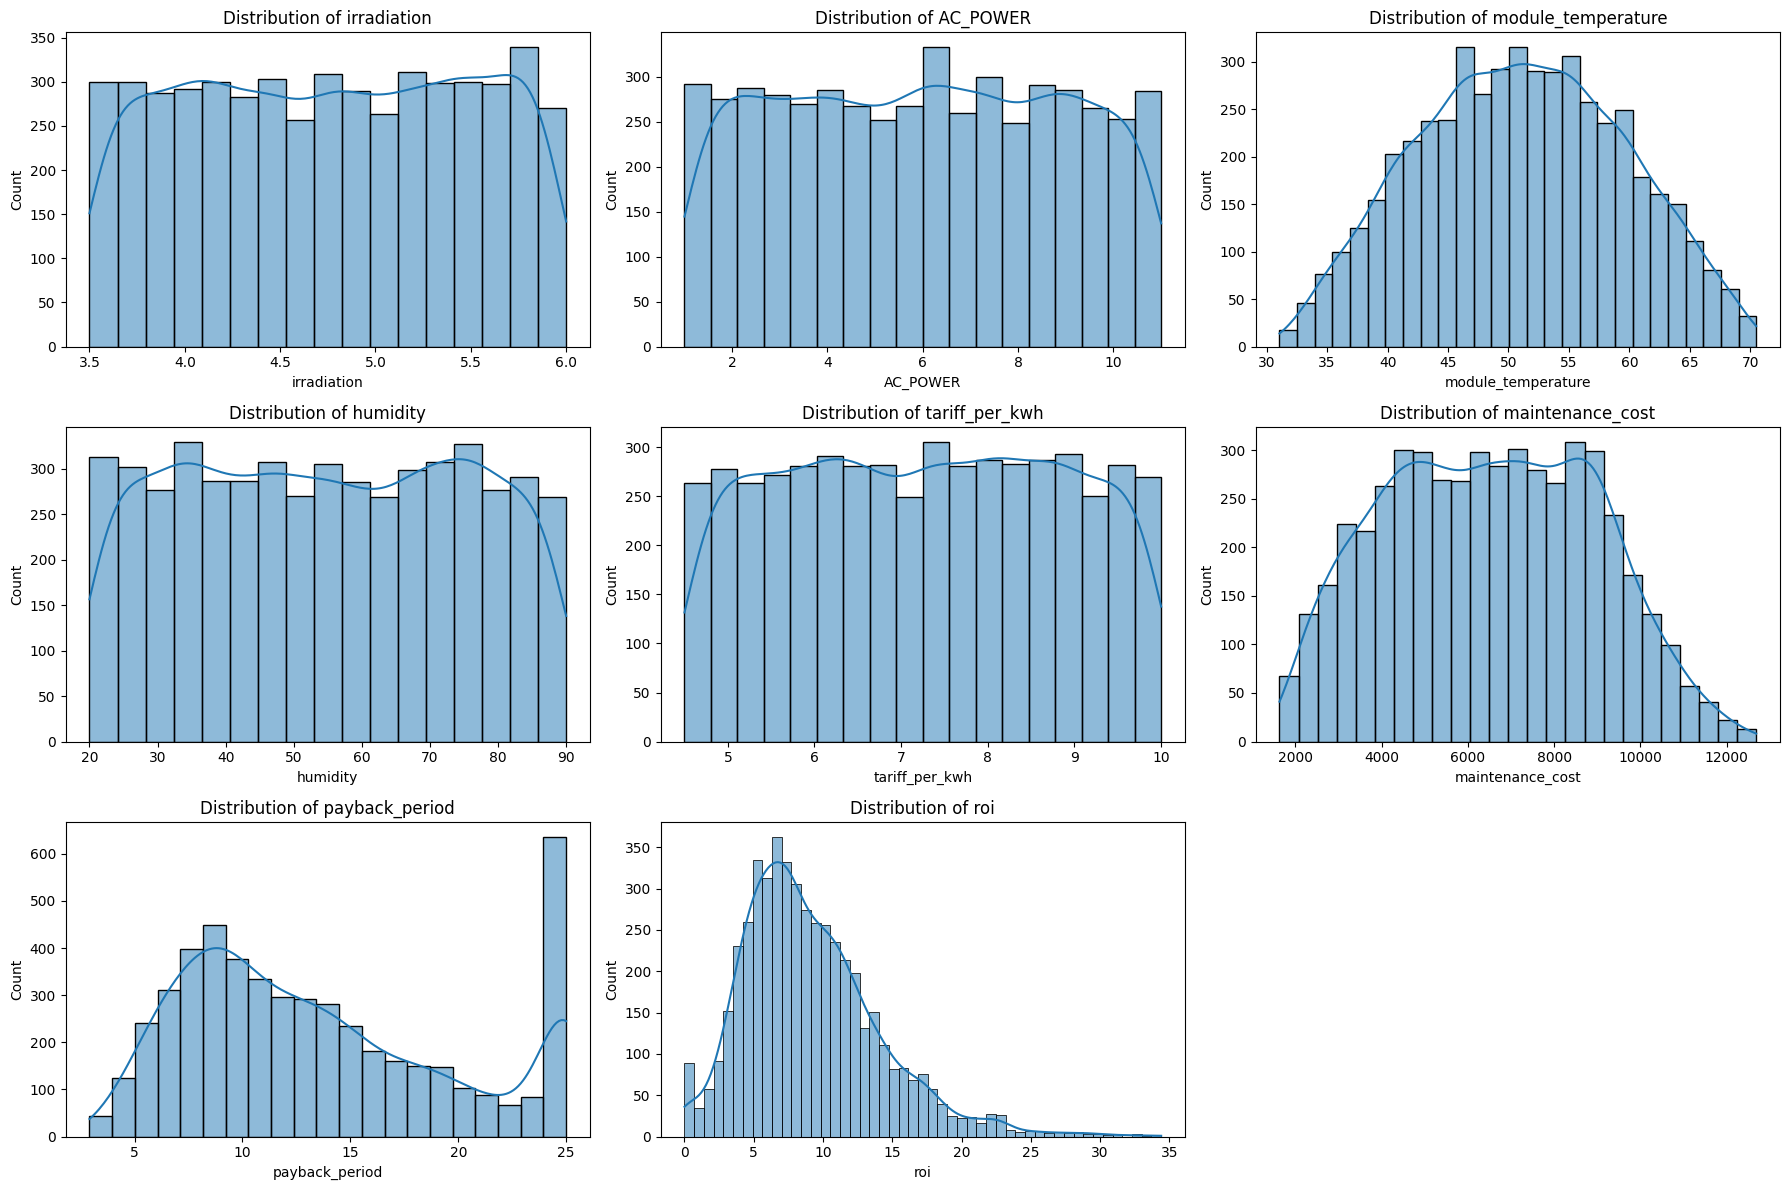

In [59]:
features = [
    'irradiation',
    'AC_POWER',
    'module_temperature',
    'humidity',
    'tariff_per_kwh',
    'maintenance_cost',
    'payback_period',
    'roi'
]

# Create 3 plots per row
fig, axes = plt.subplots(
    nrows=(len(features) + 2) // 3,
    ncols=3,
    figsize=(18, 12)
)

# Flatten axes for easy iteration
axes = axes.flatten()

for i, col in enumerate(features):

    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f'Distribution of {col}')

# Remove empty subplots if any
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()

plt.show()

### SKEWNESS ANALYSIS

In [60]:
for col in features:

    skewness = skew(df[col])

    print(f'{col}: {skewness}')

irradiation: -0.019472898731924086
AC_POWER: 0.0029376068775812604
module_temperature: 0.008205410767788137
humidity: 0.005060206726067754
tariff_per_kwh: -0.006218888205393998
maintenance_cost: 0.06748911148868965
payback_period: 0.5617146058570397
roi: 1.031433908434566


### CORRELATION ANALYSIS

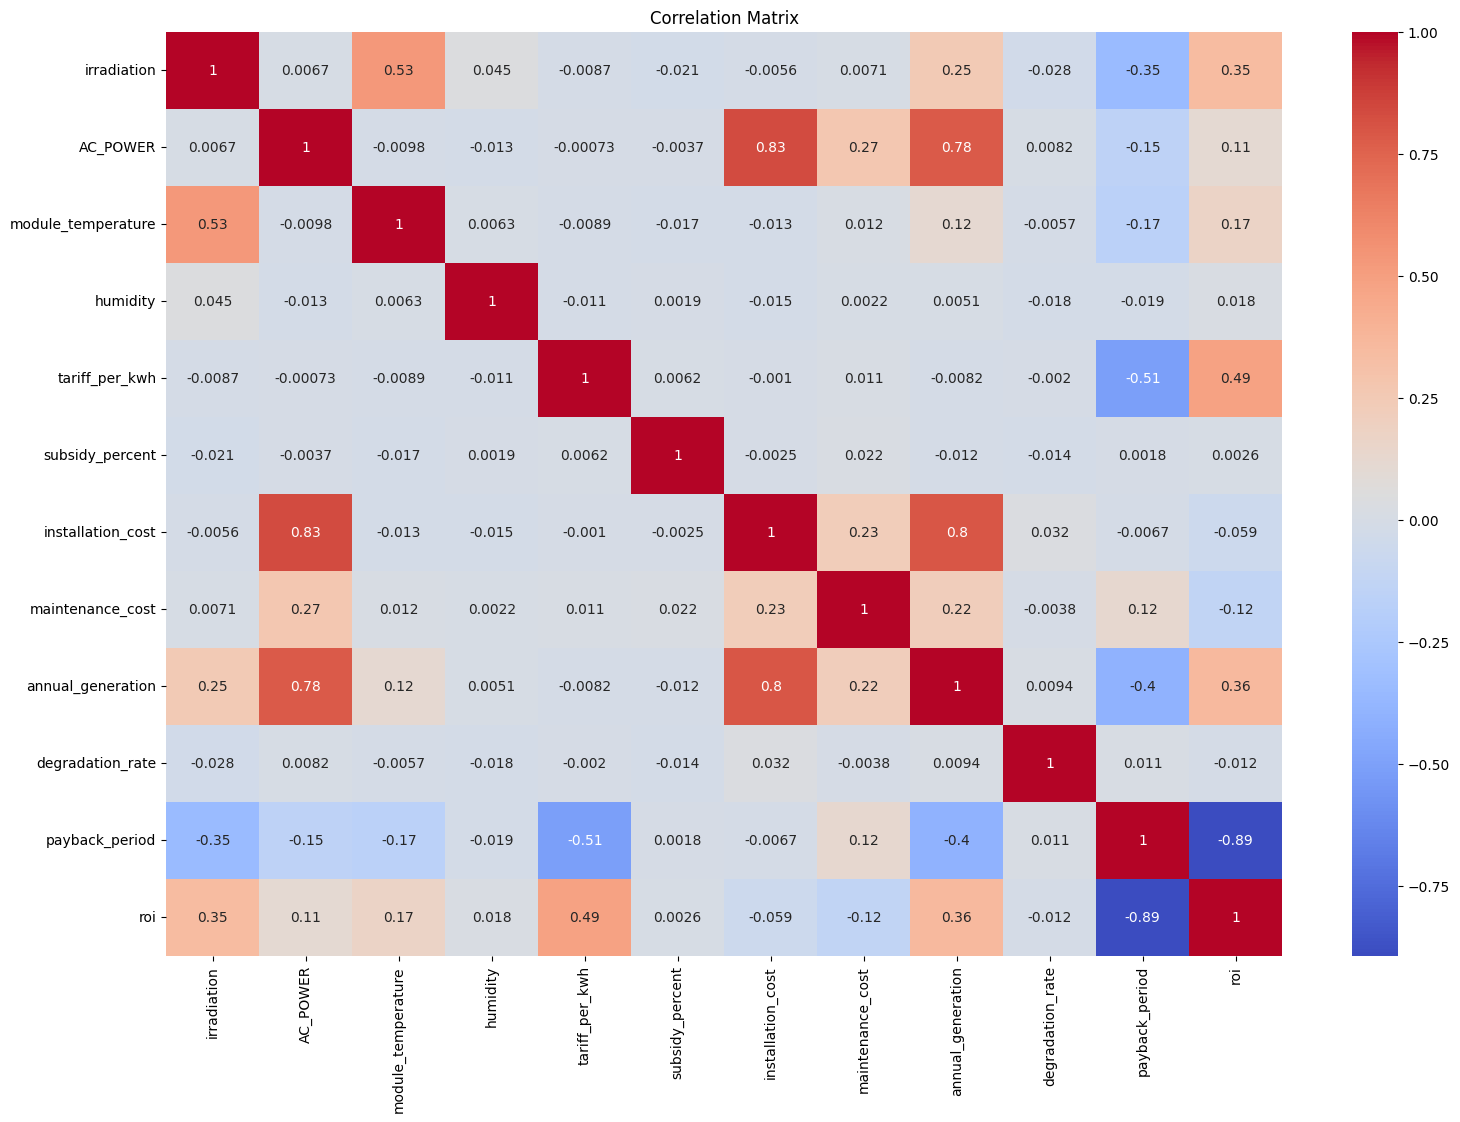

roi                   1.000000
tariff_per_kwh        0.485959
annual_generation     0.362129
irradiation           0.346558
module_temperature    0.166186
AC_POWER              0.105978
humidity              0.017747
subsidy_percent       0.002627
degradation_rate     -0.012436
installation_cost    -0.059222
maintenance_cost     -0.123844
payback_period       -0.892777
Name: roi, dtype: float64


In [66]:
### correlation matrix

corr_matrix = df.corr(
    numeric_only=True
)

plt.figure(figsize=(18,12))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True
)

plt.title('Correlation Matrix')

plt.show()

roi_corr = (
    corr_matrix['roi']
    .sort_values(ascending=False)
)

print(roi_corr)

In [67]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[
    [
       'irradiation',
    'AC_POWER',
    'tariff_per_kwh',
    'maintenance_cost',
    'roi'
    ]
]

vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

print(vif)

            Feature       VIF
0       irradiation  1.033385
1          AC_POWER  1.084540
2    tariff_per_kwh  1.060909
3  maintenance_cost  1.086430
4               roi  1.102295


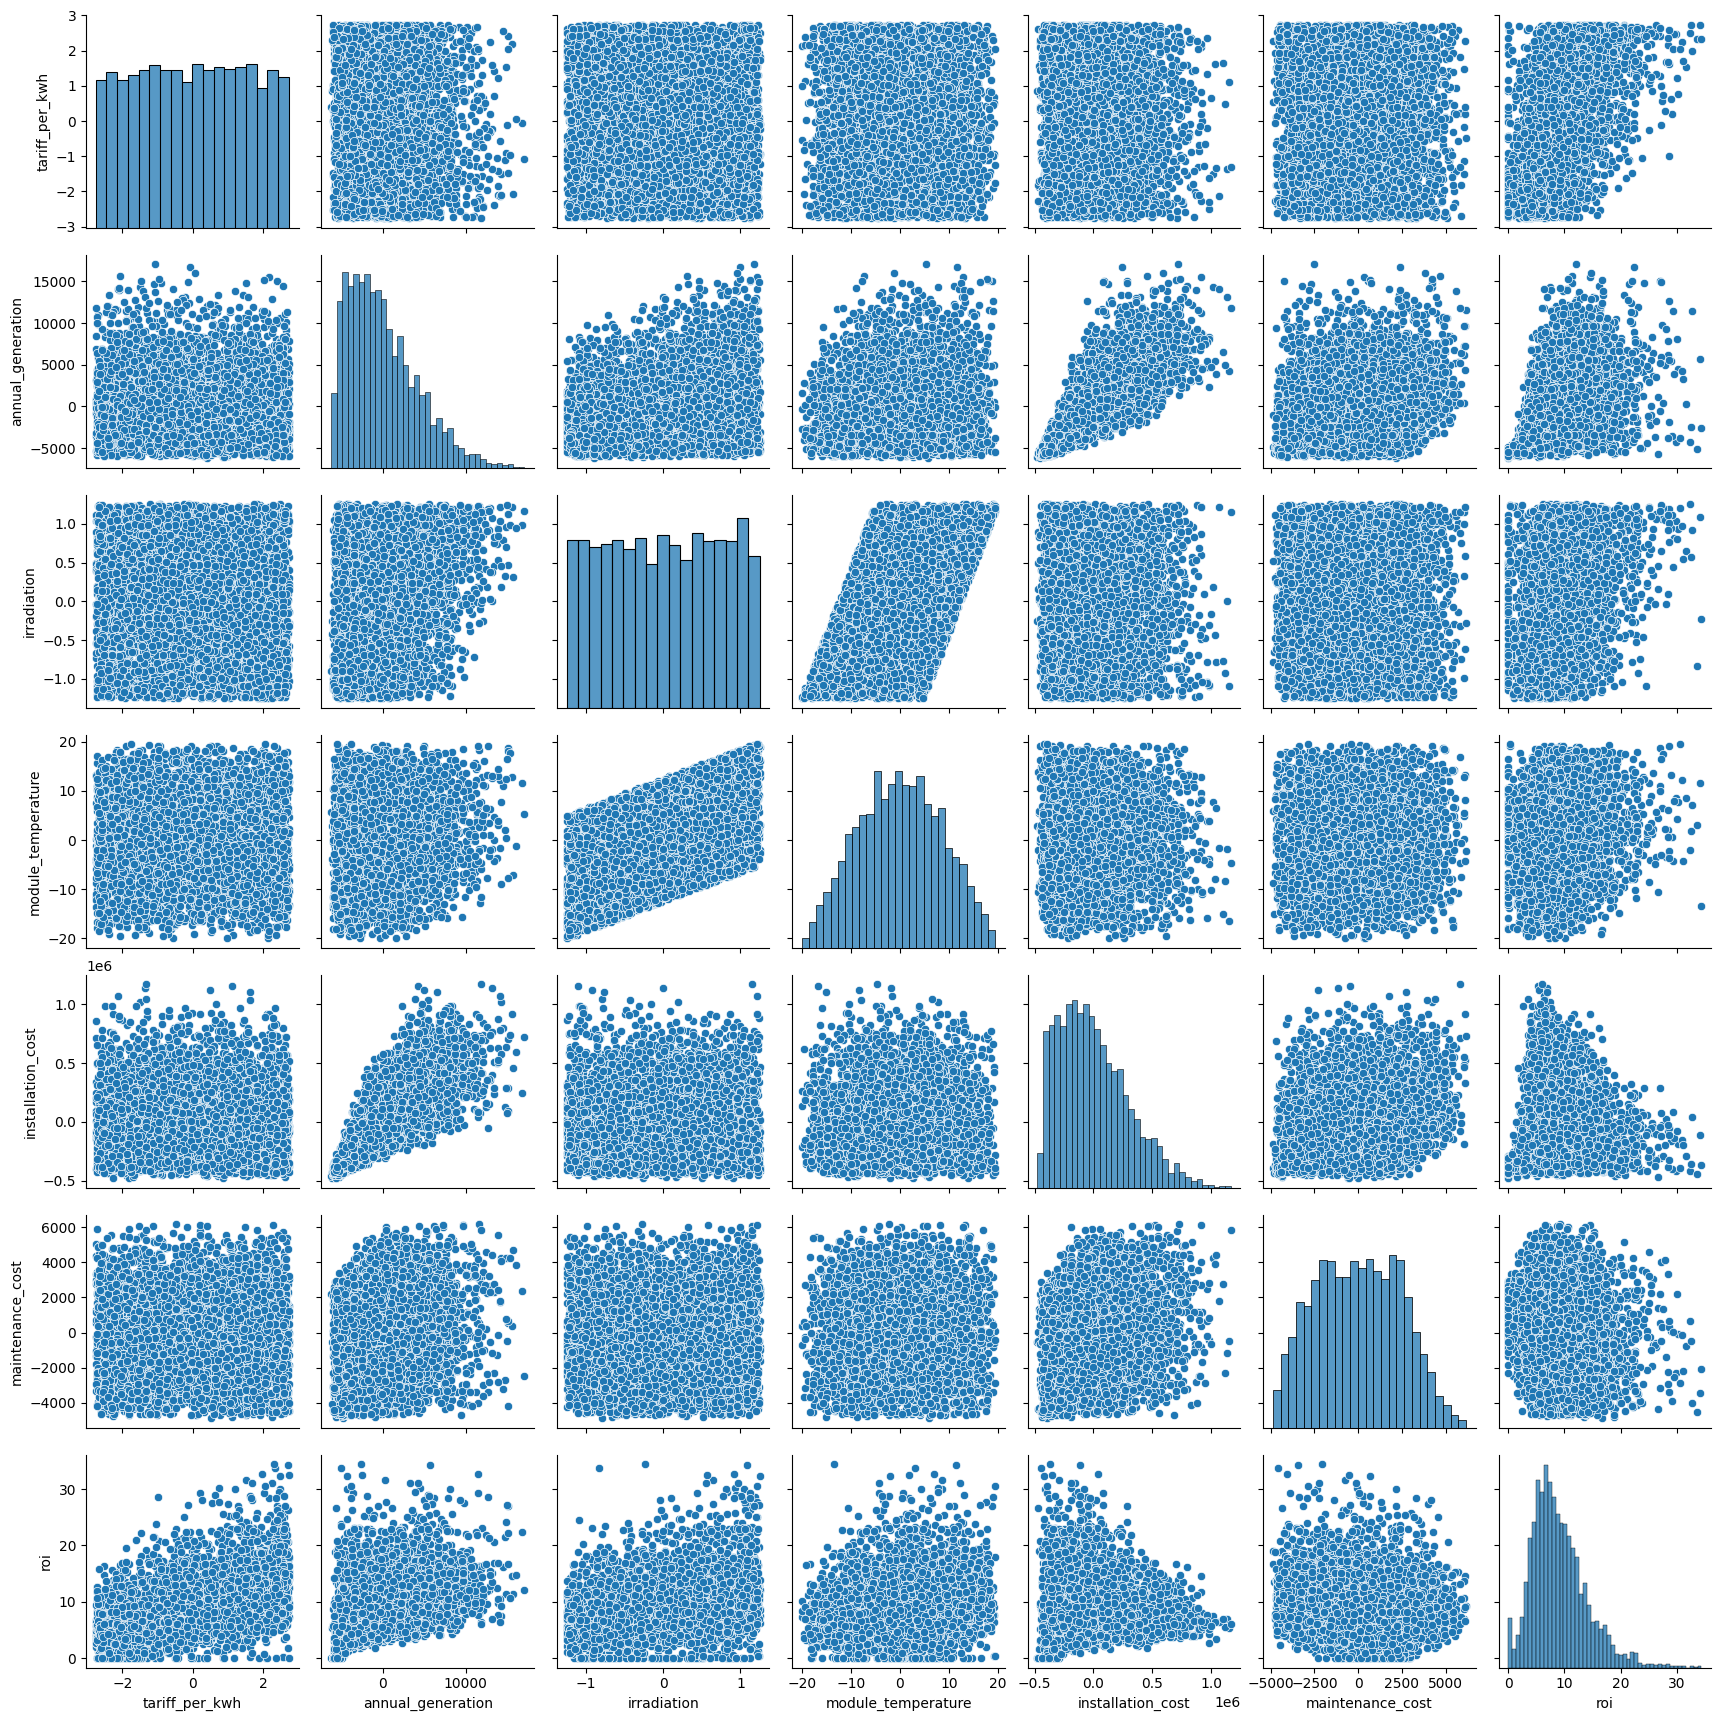

In [68]:
selected_features = [
     'tariff_per_kwh',
    'annual_generation',
    'irradiation',
    'module_temperature',
    'installation_cost',
    'maintenance_cost',
    "roi"
]

sns.pairplot(
    df[selected_features]
)

plt.show()

### OUTLIER ANALYSIS

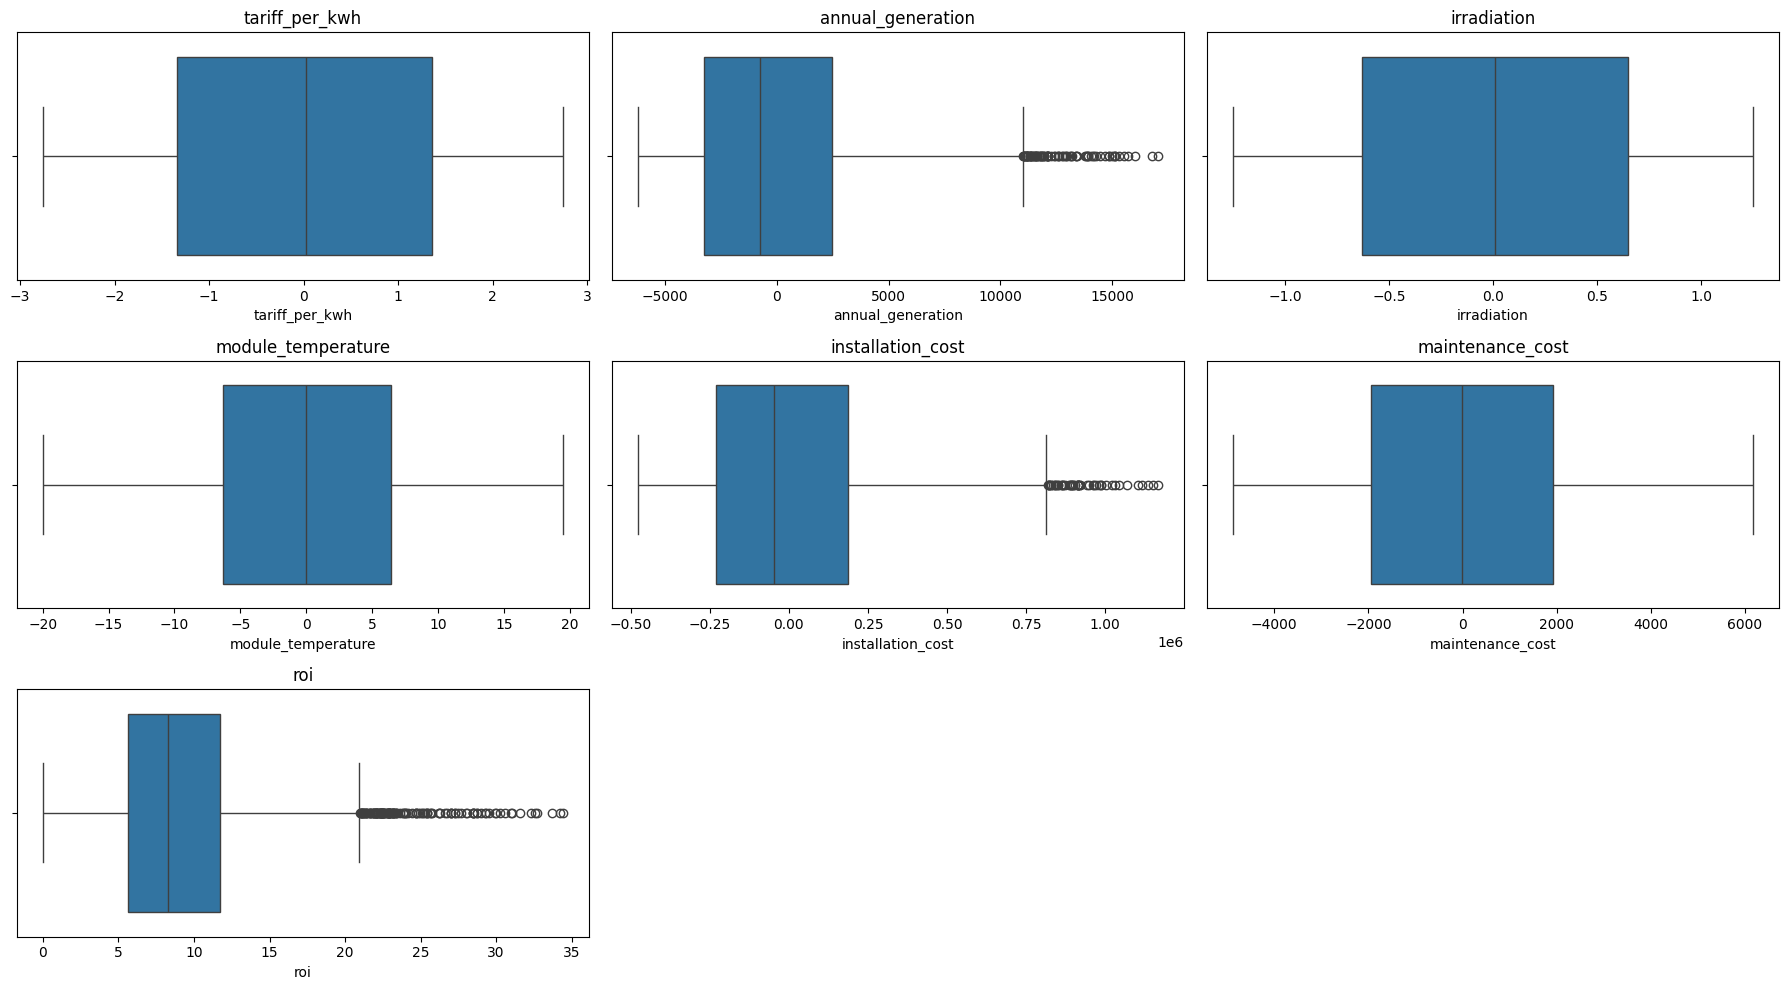

In [70]:
features = [
    'tariff_per_kwh',
    'annual_generation',
    'irradiation',
    'module_temperature',
    'installation_cost',
    'maintenance_cost',
    'roi'
]

# Create subplots with 3 plots per row
fig, axes = plt.subplots(
    nrows=(len(features) + 2) // 3,
    ncols=3,
    figsize=(18, 10)
)

# Flatten axes array
axes = axes.flatten()

# Plot boxplots
for i, col in enumerate(features):

    sns.boxplot(
        x=df[col],
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty plots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

# Adjust layout
plt.tight_layout()

plt.show()

In [71]:
Q1 = df['roi'].quantile(0.25)

Q3 = df['roi'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

filtered_df = df[
    (df['roi'] >= lower)
    &
    (df['roi'] <= upper)
]

In [72]:
print(df.shape)

print(filtered_df.shape)

(5000, 13)
(4864, 13)


### FEATURE SELECTION

In [ ]:
features = [
    'tariff_per_kwh',
    'annual_generation',
    'irradiation',
    'module_temperature',
    'installation_cost',
    'maintenance_cost',
]